# Events Information

[Event Slicer](https://github.com/uzh-rpg/DSEC/blob/main/scripts/utils/eventslicer.py): Python code from DSEC used to retrieve event data
- Fix: Cast time_array_conservative to int64 to avoid `OverflowError`


In [1]:
from utils.eventslicer import EventSlicer

In [2]:
!pip install -q hdf5plugin

# DSEC

In [4]:
import h5py
import hdf5plugin

event_path = "../data/thun_00_a/thun_00_a_events_left/events.h5"
h5f = h5py.File(event_path, 'r')
event_slicer = EventSlicer(h5f)

In [5]:
print(f"Start time (us): {event_slicer.get_start_time_us()}")
print(f"Final time (us): {event_slicer.get_final_time_us()}")
print(f"Offset (us): {event_slicer.t_offset}")

Start time (us): 49599200165
Final time (us): 49611101164
Offset (us): 49599200165


In [6]:
for key, value in event_slicer.events.items():
    print(f"  {key}: shape={value.shape}, dtype={value.dtype}")

  p: shape=(134133270,), dtype=uint8
  x: shape=(134133270,), dtype=uint16
  y: shape=(134133270,), dtype=uint16
  t: shape=(134133270,), dtype=uint32


In [7]:
# Retrieve events for the specified time window
dsec_events = event_slicer.get_events(event_slicer.get_start_time_us(), event_slicer.get_final_time_us())

# Experiment

- threshold: 0.2
- min_pixels: 0
- blur: 3x3

In [16]:
# Change offset
from utils.h5_functions import set_offset
experiment_path = "../results/experiment_generated_events.h5"
set_offset(experiment_path, event_slicer.t_offset)

In [17]:
experiment_h5f = h5py.File(experiment_path, 'r')
experiment_h5f_slicer = EventSlicer(experiment_h5f)

In [18]:
print(f"Start time (us): {experiment_h5f_slicer.get_start_time_us()}")
print(f"Final time (us): {experiment_h5f_slicer.get_final_time_us()}")
print(f"Offset (us): {experiment_h5f_slicer.t_offset}")

Start time (us): 49599200165
Final time (us): 49611050165
Offset (us): 49599200165


In [19]:
for key, value in experiment_h5f_slicer.events.items():
    print(f"  {key}: shape={value.shape}, dtype={value.dtype}")

  p: shape=(56803217,), dtype=uint8
  x: shape=(56803217,), dtype=uint16
  y: shape=(56803217,), dtype=uint16
  t: shape=(56803217,), dtype=uint64


In [20]:
# Retrieve events for the specified time window
experiment_events = experiment_h5f_slicer.get_events(experiment_h5f_slicer.get_start_time_us(), experiment_h5f_slicer.get_final_time_us())

# Stats

In [21]:
import numpy as np

def get_stats(events_dict):
    t = events_dict['t']
    p = events_dict['p']

    if len(t) == 0:
        return {
            "events": 0,
            "positive": 0,
            "negative": 0,
            "duration_us": 0,
            "events_per_sec": 0,
            "min_timestamp": 0,
            "max_timestamp": 0,
        }

    duration_us = t.max() - t.min()
    if duration_us > 0:
        events_per_sec = len(t) / (duration_us / 1e6)
    else:
        events_per_sec = 0

    return {
        "events": len(t),
        "positive": np.sum(p == 1),
        "negative": np.sum(p == 0),
        "duration_us": duration_us,
        "events_per_sec": events_per_sec,
        "min_timestamp": t.min(),
        "max_timestamp": t.max(),
    }

In [22]:
print("DSEC")
dsec_stats = get_stats(dsec_events)
print(f"min_timestamp: {dsec_stats['min_timestamp']}")
print(f"max_timestamp: {dsec_stats['max_timestamp']}")

print("\nExperiment")
experiment_stats = get_stats(experiment_events)
print(f"min_timestamp: {experiment_stats['min_timestamp']}")
print(f"max_timestamp: {experiment_stats['max_timestamp']}")

DSEC


min_timestamp: 49599200165
max_timestamp: 49611101163

Experiment
min_timestamp: 49599200165
max_timestamp: 49611000165


In [25]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 7.0 MB/s  0:00:01eta 0:00:01


In [26]:
import pandas as pd

df_stats = pd.DataFrame({
    'DSEC': dsec_stats,
    'Experiment': experiment_stats
}, index=['events', 'positive', 'negative', 'events_per_sec'])

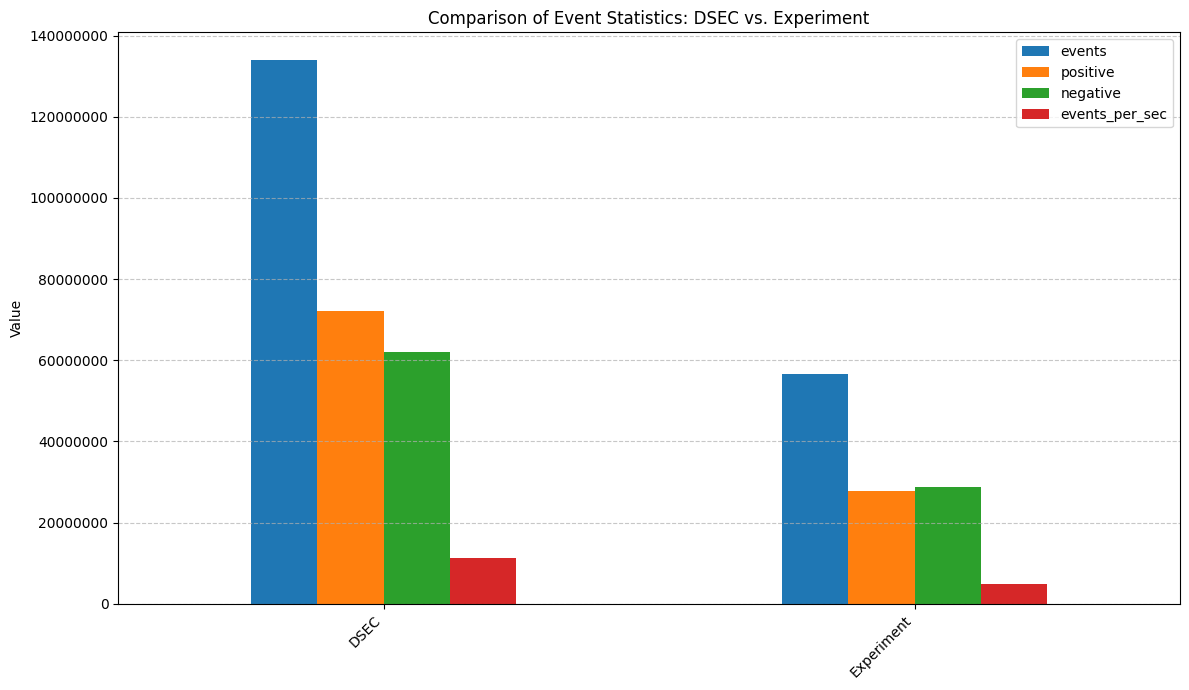

In [30]:
import matplotlib.pyplot as plt

metrics_to_plot = ['events', 'positive', 'negative', 'events_per_sec']
plot_df = df_stats.loc[metrics_to_plot]

fig, ax = plt.subplots(figsize=(12, 7))
plot_df.T.plot(kind='bar', ax=ax)

ax.set_title('Comparison of Event Statistics: DSEC vs. Experiment')
ax.set_ylabel('Value')
ax.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [28]:
percentage_events = (df_stats.loc['events', 'Experiment'] / df_stats.loc['events', 'DSEC']) * 100
print(f"Percentage of events of the experiment compared to DSEC: {percentage_events:.2f}%")

Percentage of events of the experiment compared to DSEC: 42.17%


In [31]:
pip freeze > requirements.txt 

Note: you may need to restart the kernel to use updated packages.
